# 🎬 **Netflix Data Analysis**

This project analyzes Netflix's content dataset to uncover trends in content production, genres, ratings, and growth over time using Python.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv.zip")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [31]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


# Data Cleaning

In [32]:
df.fillna("Unknown", inplace=True)

In [33]:
df["date_added"] = pd.to_datetime(df["date_added"], errors='coerce')
df["year_added"] = df["date_added"].dt

# Movies vs TV Shows

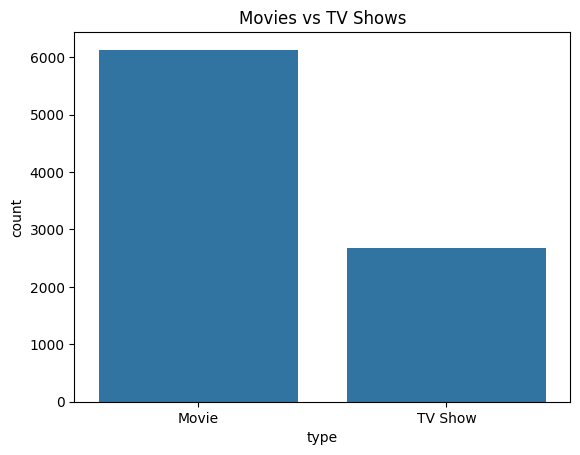

In [34]:
sns.countplot(x="type", data=df)
plt.title("Movies vs TV Shows")
plt.show()

# Content Growth Over Years

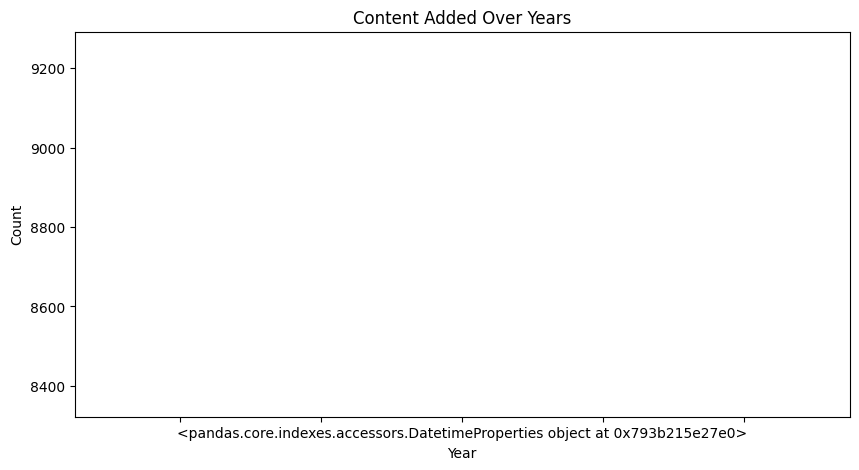

In [35]:
df["year_added"].value_counts().sort_index().plot(figsize=(10,5))
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

#Top Countries

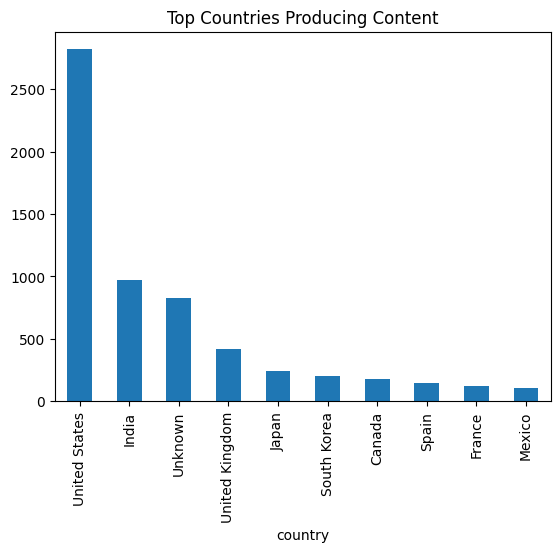

In [36]:
top_countries = df["country"].value_counts().head(10)
top_countries.plot(kind="bar")
plt.title("Top Countries Producing Content")
plt.show()


#Most Popular Genres

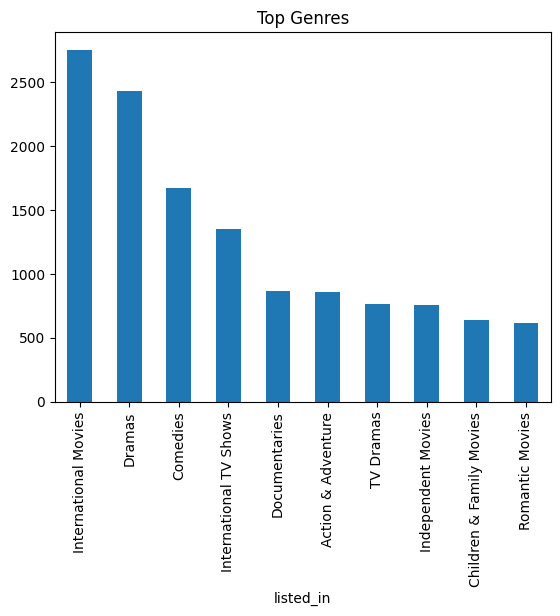

In [37]:
genres = df["listed_in"].str.split(", ").explode()
genres.value_counts().head(10).plot(kind="bar")
plt.title("Top Genres")
plt.show()


# Ratings Distribution



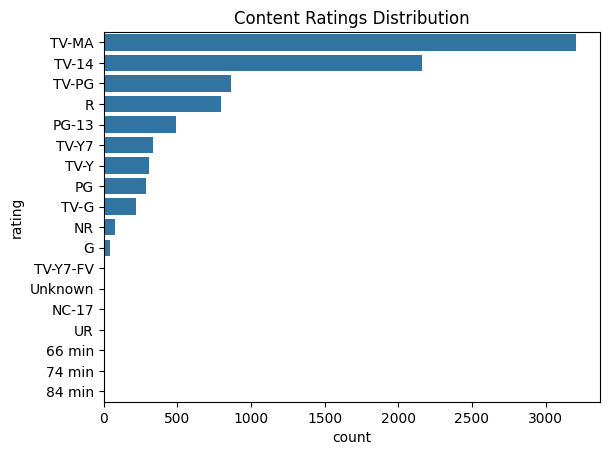

In [38]:
sns.countplot(y="rating", data=df, order=df["rating"].value_counts().index)
plt.title("Content Ratings Distribution")
plt.show()

# Movies Duration Analysis

/tmp/ipykernel_8323/2786377149.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies["duration"] = movies["duration"].str.replace(" min", "")
/tmp/ipykernel_8323/2786377149.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")


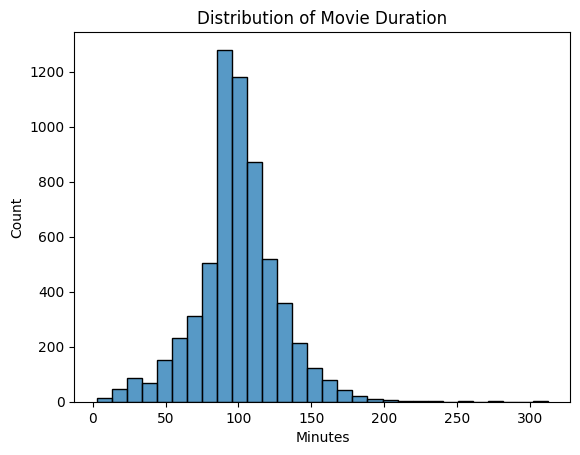

In [39]:
movies = df[df["type"] == "Movie"]

movies["duration"] = movies["duration"].str.replace(" min", "")
movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

sns.histplot(movies["duration"], bins=30)
plt.title("Distribution of Movie Duration")
plt.xlabel("Minutes")
plt.show()

# TV Shows Seasons Analysis

/tmp/ipykernel_8323/3933857480.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shows["duration"] = shows["duration"].str.replace(" Season", "").str.replace("s", "")
/tmp/ipykernel_8323/3933857480.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shows["duration"] = pd.to_numeric(shows["duration"], errors="coerce")


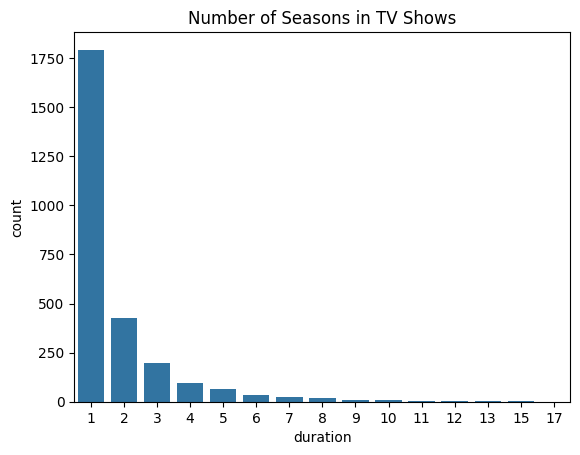

In [40]:
shows = df[df["type"] == "TV Show"]

shows["duration"] = shows["duration"].str.replace(" Season", "").str.replace("s", "")
shows["duration"] = pd.to_numeric(shows["duration"], errors="coerce")

sns.countplot(x="duration", data=shows)
plt.title("Number of Seasons in TV Shows")
plt.show()

# Monthly Trend

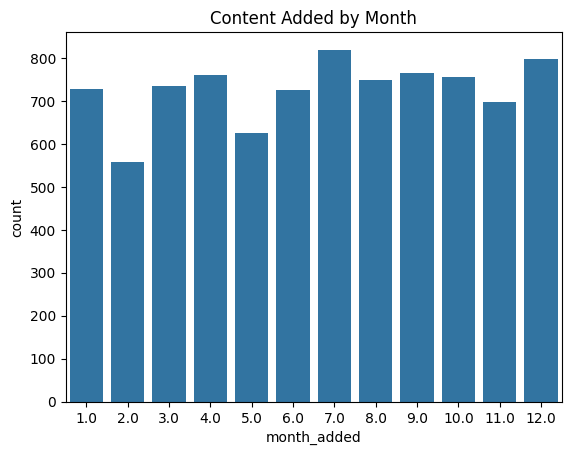

In [41]:
df["month_added"] = df["date_added"].dt.month

sns.countplot(x="month_added", data=df)
plt.title("Content Added by Month")
plt.show()

# Top Directors

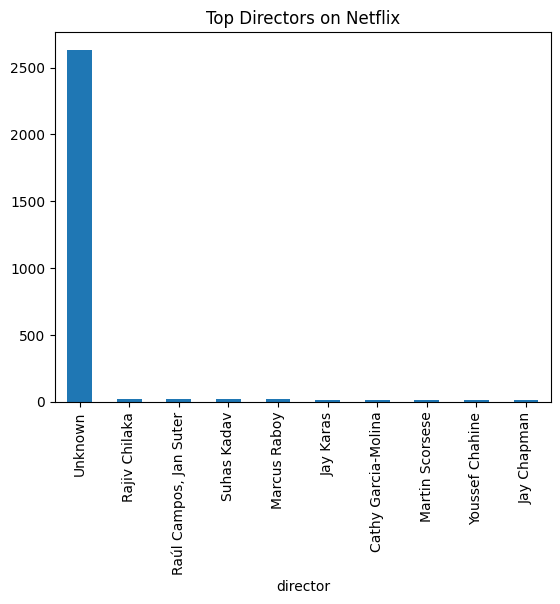

In [42]:
top_directors = df["director"].value_counts().head(10)

top_directors.plot(kind="bar")
plt.title("Top Directors on Netflix")
plt.show()

# Content Type by Country

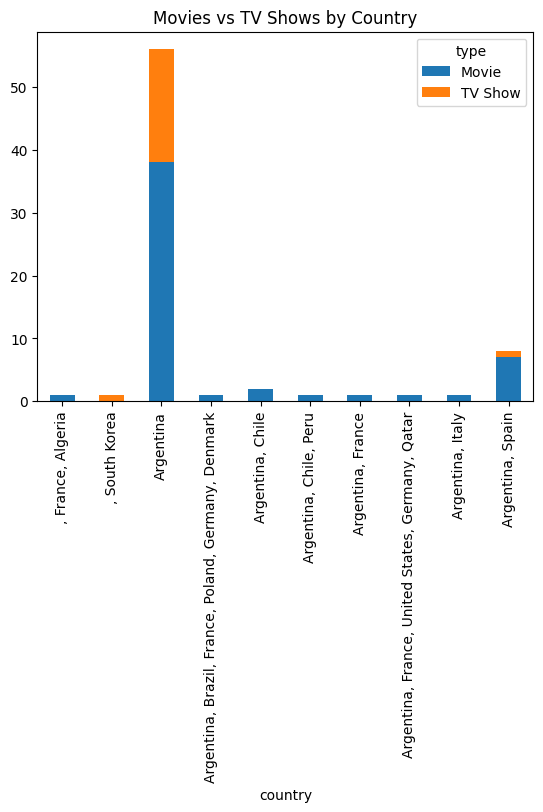

In [43]:
country_type = df.groupby(["country", "type"]).size().unstack().fillna(0)
country_type.head(10).plot(kind="bar", stacked=True)
plt.title("Movies vs TV Shows by Country")
plt.show()

# Heatmap

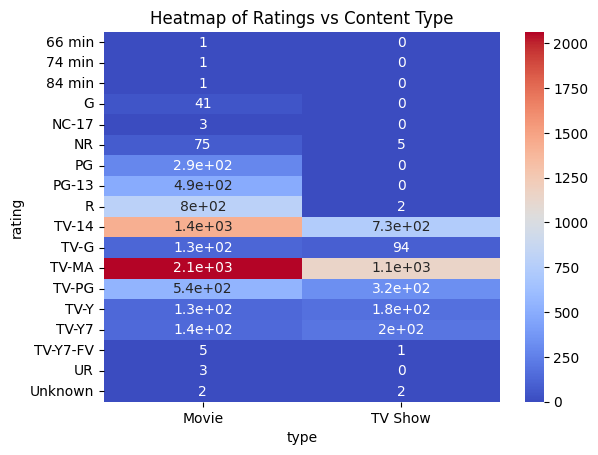

In [44]:
pivot = df.pivot_table(index="rating", columns="type", aggfunc="size", fill_value=0)

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Heatmap of Ratings vs Content Type")
plt.show()

## 📌 **Conclusion**

- Netflix content has grown significantly after 2015  
- Movies dominate over TV shows  
- USA leads content production  
- Most content targets mature audiences  
- Short-duration content is more common  